# Численные методы №2.6

In [ ]:
from numpy import log, log10, sqrt, cos, ones_like, linspace
import matplotlib.pyplot as plt
import pandas as pd

## Задание 1.

Найдите методом половинного деления корень трансцендент ного уравнения lg(x) - cos(x) = 0 с четырьмя знаками после запятой. Корни отделите графически.

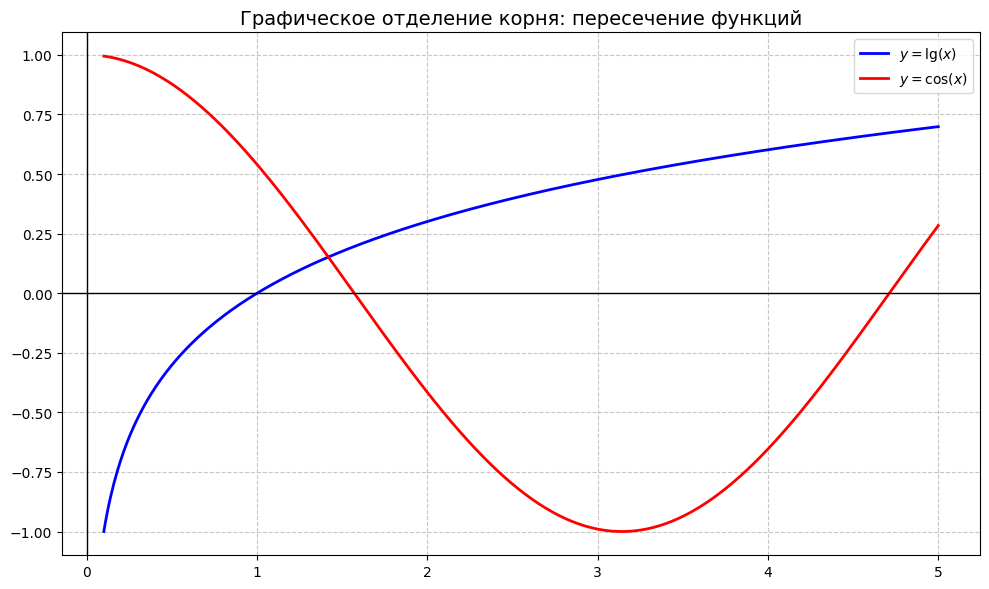

In [ ]:
# Определяем функции
def f1(x):
    return log10(x)

def f2(x):
    return cos(x)

def f_diff(x):
    return f1(x) - f2(x)

# Задаем диапазон x (от 0.1, так как lg(0) не определен)
x = linspace(0.1, 5, 500)

# Создаем полотно с двумя графиками
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Верхний график: Пересечение функций ---
ax1.plot(x, f1(x), label=r'$y = \lg(x)$', color='blue', linewidth=2)
ax1.plot(x, f2(x), label=r'$y = \cos(x)$', color='red', linewidth=2)
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_title('Графическое отделение корня: пересечение функций', fontsize=14)
ax1.legend()

plt.tight_layout()
plt.show()

In [ ]:
def f(x):
    # В Python log10 — это десятичный логарифм (lg)
    return log10(x) - cos(x)

def bisection_method(a, b, eps):
    if f(a) * f(b) > 0:
        print("Ошибка: знаки функции на концах отрезка одинаковы.")
        return None
    
    iteration = 0
    while (b - a) / 2 > eps:
        iteration += 1
        c = (a + b) / 2
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    return round((a + b) / 2, 4)

# Параметры
a, b = 1.0, 2.0
epsilon = 0.0001

root = bisection_method(a, b, epsilon)
print(f"Корень уравнения: {root}")

Корень уравнения: 1.4184


## Задание 2.

Отделите графически корни уравнения x^2 - 3.2x = 1 Найдите одним из итерационных методов действительный корень данного уравнения с точностью 10^-4.

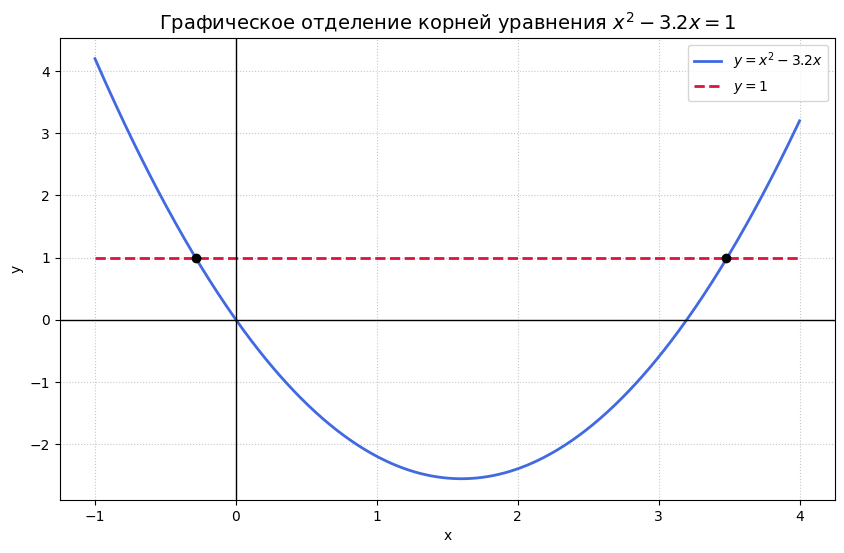

In [ ]:
# Определяем функции
def f1(x):
    return x**2 - 3.2*x

def f2(x):
    return ones_like(x)  # Прямая y = 1

# Генерируем значения x для построения
x = linspace(-1, 4, 500)

plt.figure(figsize=(10, 6))

# Строим графики
plt.plot(x, f1(x), label=r'$y = x^2 - 3.2x$', color='royalblue', linewidth=2)
plt.plot(x, f2(x), label=r'$y = 1$', color='crimson', linestyle='--', linewidth=2)

# Оформление осей
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.7)

# Отметка корней (приблизительно)
roots_approx = [-0.28, 3.48]
plt.scatter(roots_approx, [1, 1], color='black', zorder=5)

plt.title('Графическое отделение корней уравнения $x^2 - 3.2x = 1$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

In [ ]:
def solve_iterations_pandas(x0, eps):
    # Уравнение: x^2 - 3.2x - 1 = 0
    # Итерационная формула: x = sqrt(3.2x + 1)
    phi = lambda x: sqrt(3.2 * x + 1)
    
    data = []
    x_prev = x0
    iteration = 0
    
    while True:
        iteration += 1
        x_next = phi(x_prev)
        diff = abs(x_next - x_prev)
        
        # Добавляем данные в список
        data.append({
            'Итерация': iteration,
            'x_n': x_next,
            'Погрешность (|x_n - x_{n-1}|)': diff
        })
        
        if diff < eps:
            break
        x_prev = x_next
        
    # Создаем DataFrame
    df = pd.DataFrame(data)
    
    # Настройка отображения для красоты
    pd.options.display.float_format = '{:.6f}'.format
    
    return df

# Параметры
x_start = 3.5  # начальное приближение из графического анализа
precision = 0.0001

# Получаем таблицу
result_df = solve_iterations_pandas(x_start, precision)

# Вывод через display
print("Процесс уточнения корня:")
display(result_df)

root = result_df['x_n'].iloc[-1]
print(f"\nИтоговый корень с точностью 10^-4: {root:.4f}")

Процесс уточнения корня:


,Итерация,x_n,Погрешность (|x_n - x_{n-1}|)
0,1,3.492850,0.007150
1,2,3.489573,0.003277
2,3,3.488070,0.001503
3,4,3.487381,0.000689
4,5,3.487064,0.000316
5,6,3.486919,0.000145
6,7,3.486853,0.000067



Итоговый корень с точностью 10^-4: 3.4869


## Задание 3.

Найдите наибольший положительный корень уравнения 4x - 3*ln(x) = 4 с точностью 10^-4, используя метод итераций. Корни отделите графически.

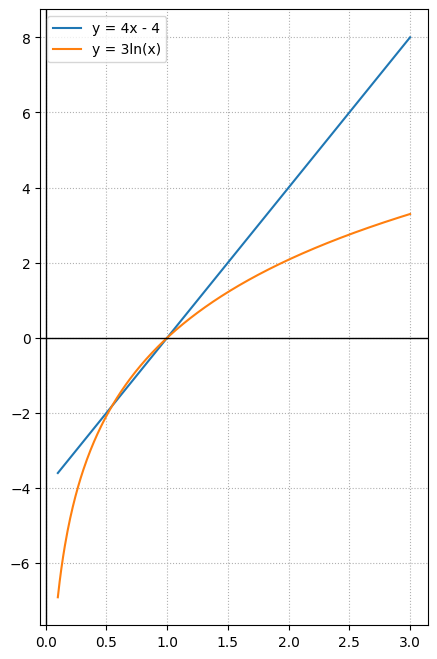

In [ ]:
x = linspace(0.1, 3, 400)
y1 = 4 * x - 4
y2 = 3 * log(x)

plt.figure(figsize=(5, 8))
plt.plot(x, y1, label='y = 4x - 4')
plt.plot(x, y2, label='y = 3ln(x)')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

In [ ]:
def solve():
    # Итерационная функция x = (3*ln(x) + 4) / 4
    phi = lambda x: (3 * log(x) + 4) / 4
    
    eps = 1e-4
    x_prev = 2.0  # Начальное приближение для наибольшего корня
    data = []
    iteration = 0
    
    while True:
        iteration += 1
        x_next = phi(x_prev)
        diff = abs(x_next - x_prev)
        
        data.append({
            "Итерация": iteration,
            "x_n": x_next,
            "|x_n - x_{n-1}|": diff
        })
        
        if diff < eps:
            break
        x_prev = x_next
        
    df = pd.DataFrame(data)
    pd.options.display.float_format = '{:.6f}'.format
    return df

result_df = solve()
display(result_df)
print(f"\nНаибольший корень: {result_df['x_n'].iloc[-1]:.4f}")

,Итерация,x_n,|x_n - x_{n-1}|
0,1,1.519860,0.480140
1,2,1.313964,0.205897
2,3,1.204786,0.109178
3,4,1.139727,0.065060
4,5,1.098091,0.041635
5,6,1.070180,0.027911
6,7,1.050870,0.019310
7,8,1.037214,0.013656
8,9,1.027404,0.009810
9,10,1.020276,0.007127



Наибольший корень: 1.0003
